In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Sine Signal

sampling_rate = 1000 # samples per seconds
T = 1 # seconds
t = np.linspace(0,T, sampling_rate*T, endpoint = False) # Time vector
frequency = 5 # frequency of the sine signal
amplitude = 1 # Amplitude of the sine signal

In [23]:
# Original Signal(Sine Wave)

signal = amplitude*np.sin(2*np.pi*frequency*t)

In [24]:
# Adding noise to the signal

noise_amplitude = 0.5
noise = noise_amplitude*np.random.normal(size = t.shape)

noisy_signal = signal + noise

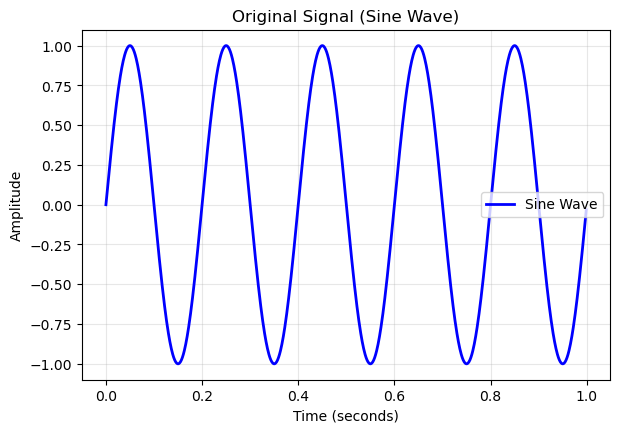

In [25]:
# Create the plot
plt.figure(figsize=(15, 10))

# Plot 1: Original Sine Wave
plt.subplot(2, 2, 1)
plt.plot(t, signal, 'b-', linewidth=2, label='Sine Wave')
plt.title('Original Signal (Sine Wave)')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

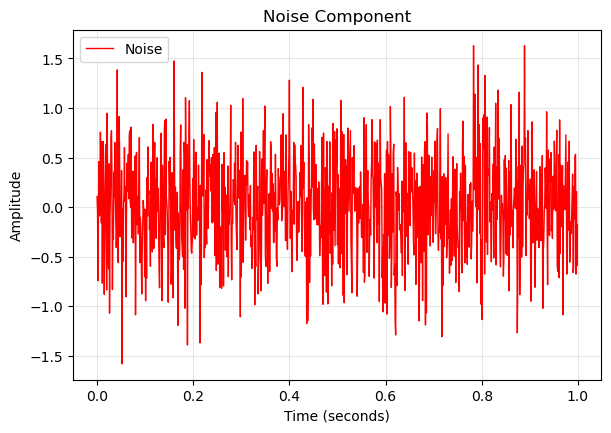

In [26]:
# Plot 2: Noise Only

plt.figure(figsize = (15,10))

plt.subplot(2, 2, 2)
plt.plot(t, noise, 'r-', linewidth=1, label='Noise')
plt.title('Noise Component')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

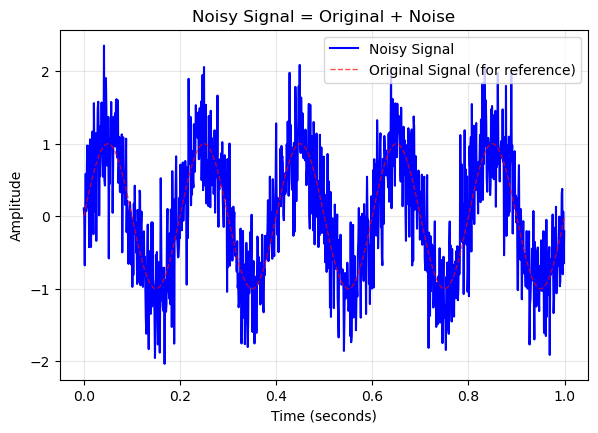

In [27]:
# Plot the noisy signal

plt.figure(figsize = (15,10))

plt.subplot(2, 2, 3)
plt.plot(t, noisy_signal, 'b-', linewidth=1.5, label='Noisy Signal')
plt.plot(t, signal, 'r--', linewidth=1, alpha=0.7, label='Original Signal (for reference)')
plt.title('Noisy Signal = Original + Noise')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [28]:
# DFT to noisy signal

dft_result = np.fft.fft(noisy_signal)
frequecies = np.fft.fftfreq(t.size, d = 1/sampling_rate)

In [31]:
magnitude = np.abs(dft_result)

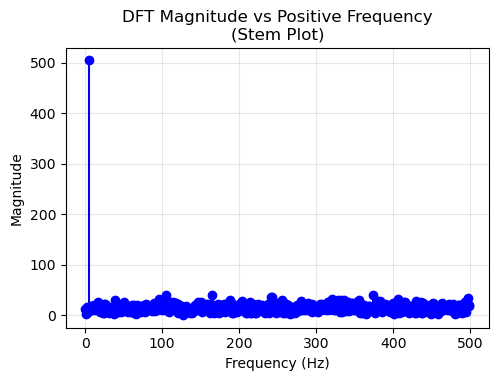

In [34]:
# Get only positive frequencies (0 to Nyquist frequency)
positive_mask = frequencies >= 0
positive_frequencies = frequencies[positive_mask]
positive_magnitude = magnitude[positive_mask]

# Create the plot
plt.figure(figsize=(12, 8))

# Plot 1: Stem plot (most common for DFT)
plt.subplot(2, 2, 1)
plt.stem(positive_frequencies, positive_magnitude, linefmt='blue', markerfmt='bo', basefmt=' ')
plt.title('DFT Magnitude vs Positive Frequency\n(Stem Plot)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True, alpha=0.3)
plt.show()

In [48]:
# Define a frequency for the low pass filter

cutoff_frequency = 9 # Have to optimize it accordingly

In [49]:
# Create a boolean mask for the frequencies

mask = np.abs(frequencies) >= cutoff_frequency

In [50]:
# Apply the mask to zero out high frequency component

filtered_dft = dft_result.copy()
filtered_dft[mask] = 0

In [53]:
# Compute the IDFT to get back to time domain

idft_result = np.fft.ifft(filtered_dft)

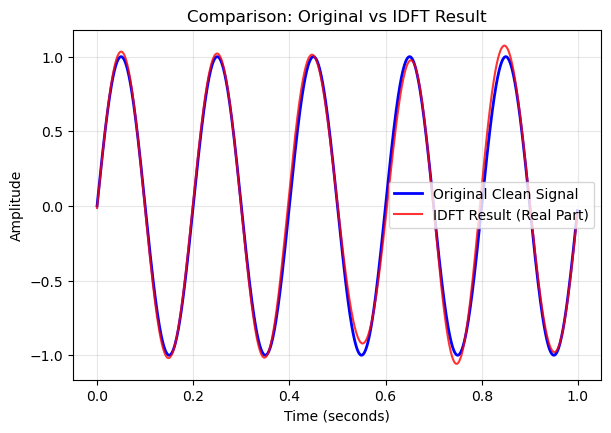

In [54]:
# Plot the IDFT result against time
plt.figure(figsize=(15, 10))

# Plot 1: Original clean signal vs IDFT result
plt.subplot(2, 2, 1)
plt.plot(t, signal, 'b-', linewidth=2, label='Original Clean Signal')
plt.plot(t, idft_result.real, 'r-', linewidth=1.5, alpha=0.8, label='IDFT Result (Real Part)')
plt.title('Comparison: Original vs IDFT Result')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()